# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

- Nama: Putri Prayesti
- Email: aeiprsty@gmail.com
- Id Dicoding: pppiiiy

## Persiapan

### Menyiapkan library yang dibutuhkan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import joblib

### Menyiapkan data yang akan digunakan

In [6]:
df = pd.read_csv("data.csv", sep=";")

df.head()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## Data Understanding

In [7]:
print(f"Jumlah baris: {df.shape[0]}")
print(f"Jumlah kolom: {df.shape[1]}")

Jumlah baris: 4424
Jumlah kolom: 37


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                         4424 non-null   int64  
 10 

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Marital_status,4424.0,1.178571,0.605747,1.00,1.00,1.000000,1.000000,6.000000
Application_mode,4424.0,18.669078,17.484682,1.00,1.00,17.000000,39.000000,57.000000
Application_order,4424.0,1.727848,1.313793,0.00,1.00,1.000000,2.000000,9.000000
Course,4424.0,8856.642631,2063.566416,33.00,9085.00,9238.000000,9556.000000,9991.000000
Daytime_evening_attendance,4424.0,0.890823,0.311897,0.00,1.00,1.000000,1.000000,1.000000
Previous_qualification,4424.0,4.577758,10.216592,1.00,1.00,1.000000,1.000000,43.000000
Previous_qualification_grade,4424.0,132.613314,13.188332,95.00,125.00,133.100000,140.000000,190.000000
Nacionality,4424.0,1.873192,6.914514,1.00,1.00,1.000000,1.000000,109.000000
Mothers_qualification,4424.0,19.561935,15.603186,1.00,2.00,19.000000,37.000000,44.000000
Fathers_qualification,4424.0,22.275316,15.343108,1.00,3.00,19.000000,37.000000,44.000000


In [10]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0]

Series([], dtype: int64)

In [11]:
duplicate_count = df.duplicated().sum()

print(f"Jumlah data duplikat: {duplicate_count}")

Jumlah data duplikat: 0


In [12]:
df.columns.tolist()

['Marital_status',
 'Application_mode',
 'Application_order',
 'Course',
 'Daytime_evening_attendance',
 'Previous_qualification',
 'Previous_qualification_grade',
 'Nacionality',
 'Mothers_qualification',
 'Fathers_qualification',
 'Mothers_occupation',
 'Fathers_occupation',
 'Admission_grade',
 'Displaced',
 'Educational_special_needs',
 'Debtor',
 'Tuition_fees_up_to_date',
 'Gender',
 'Scholarship_holder',
 'Age_at_enrollment',
 'International',
 'Curricular_units_1st_sem_credited',
 'Curricular_units_1st_sem_enrolled',
 'Curricular_units_1st_sem_evaluations',
 'Curricular_units_1st_sem_approved',
 'Curricular_units_1st_sem_grade',
 'Curricular_units_1st_sem_without_evaluations',
 'Curricular_units_2nd_sem_credited',
 'Curricular_units_2nd_sem_enrolled',
 'Curricular_units_2nd_sem_evaluations',
 'Curricular_units_2nd_sem_approved',
 'Curricular_units_2nd_sem_grade',
 'Curricular_units_2nd_sem_without_evaluations',
 'Unemployment_rate',
 'Inflation_rate',
 'GDP',
 'Status']

In [13]:
status_counts = df["Status"].value_counts()

print(status_counts)

Status
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


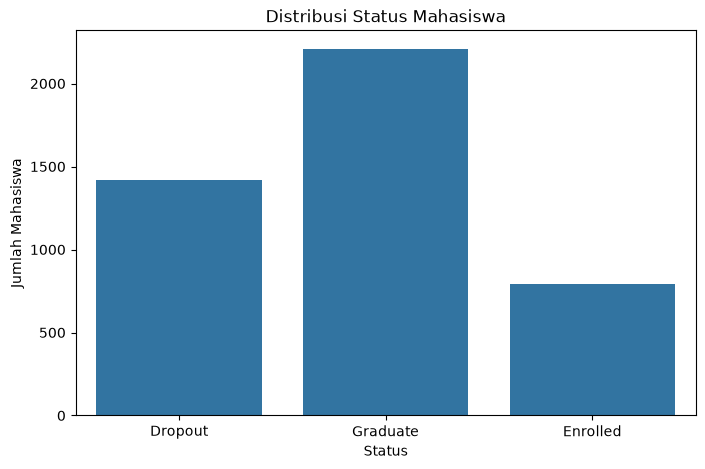

In [14]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="Status")

plt.title("Distribusi Status Mahasiswa")
plt.xlabel("Status")
plt.ylabel("Jumlah Mahasiswa")
plt.show()

In [15]:
status_percentage = df["Status"].value_counts(normalize=True) * 100

print(status_percentage.round(2))

Status
Graduate    49.93
Dropout     32.12
Enrolled    17.95
Name: proportion, dtype: float64


In [16]:
academic_features = [
    "Curricular_units_1st_sem_enrolled",
    "Curricular_units_1st_sem_evaluations",
    "Curricular_units_1st_sem_approved",
    "Curricular_units_1st_sem_grade",
    "Curricular_units_2nd_sem_enrolled",
    "Curricular_units_2nd_sem_evaluations",
    "Curricular_units_2nd_sem_approved",
    "Curricular_units_2nd_sem_grade"
]

df[academic_features].describe().T

,count,mean,std,min,25%,50%,75%,max
Curricular_units_1st_sem_enrolled,4424.0,6.270570,2.480178,0.0,5.00,6.000000,7.000000,26.000000
Curricular_units_1st_sem_evaluations,4424.0,8.299051,4.179106,0.0,6.00,8.000000,10.000000,45.000000
Curricular_units_1st_sem_approved,4424.0,4.706600,3.094238,0.0,3.00,5.000000,6.000000,26.000000
Curricular_units_1st_sem_grade,4424.0,10.640822,4.843663,0.0,11.00,12.285714,13.400000,18.875000
Curricular_units_2nd_sem_enrolled,4424.0,6.232143,2.195951,0.0,5.00,6.000000,7.000000,23.000000
Curricular_units_2nd_sem_evaluations,4424.0,8.063291,3.947951,0.0,6.00,8.000000,10.000000,33.000000
Curricular_units_2nd_sem_approved,4424.0,4.435805,3.014764,0.0,2.00,5.000000,6.000000,20.000000
Curricular_units_2nd_sem_grade,4424.0,10.230206,5.210808,0.0,10.75,12.200000,13.333333,18.571429


In [17]:
df.groupby("Status")[academic_features].mean().round(2)

,Curricular_units_1st_sem_enrolled,Curricular_units_1st_sem_evaluations,Curricular_units_1st_sem_approved,Curricular_units_1st_sem_grade,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade
Status,,,,,,,,
Dropout,5.82,7.75,2.55,7.26,5.78,7.17,1.94,5.90
Enrolled,5.96,9.34,4.32,11.13,5.94,9.44,4.06,11.12
Graduate,6.67,8.28,6.23,12.64,6.63,8.14,6.18,12.70


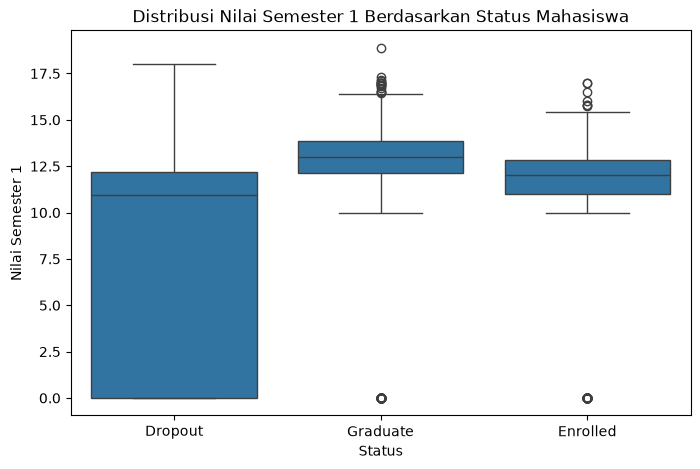

In [18]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Status",
    y="Curricular_units_1st_sem_grade"
)

plt.title("Distribusi Nilai Semester 1 Berdasarkan Status Mahasiswa")
plt.xlabel("Status")
plt.ylabel("Nilai Semester 1")
plt.show()

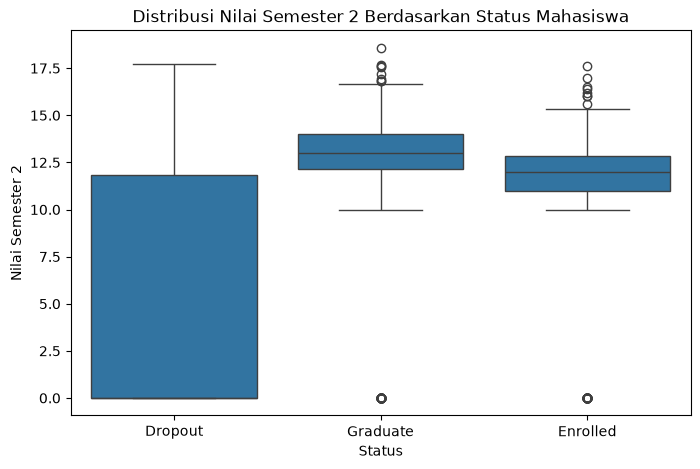

In [19]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Status",
    y="Curricular_units_2nd_sem_grade"
)

plt.title("Distribusi Nilai Semester 2 Berdasarkan Status Mahasiswa")
plt.xlabel("Status")
plt.ylabel("Nilai Semester 2")
plt.show()

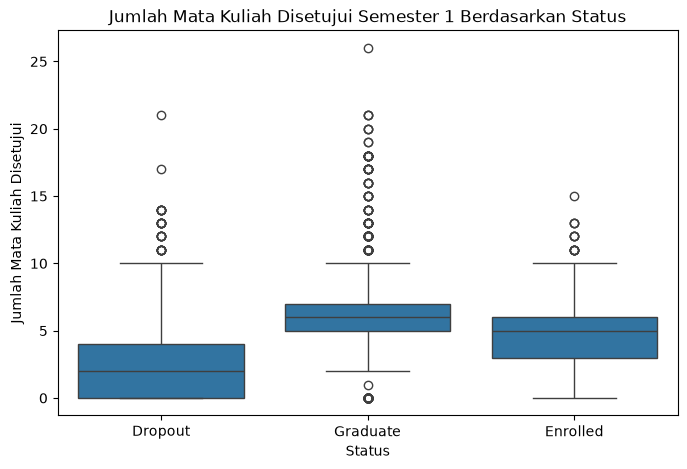

In [20]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Status",
    y="Curricular_units_1st_sem_approved"
)

plt.title("Jumlah Mata Kuliah Disetujui Semester 1 Berdasarkan Status")
plt.xlabel("Status")
plt.ylabel("Jumlah Mata Kuliah Disetujui")
plt.show()

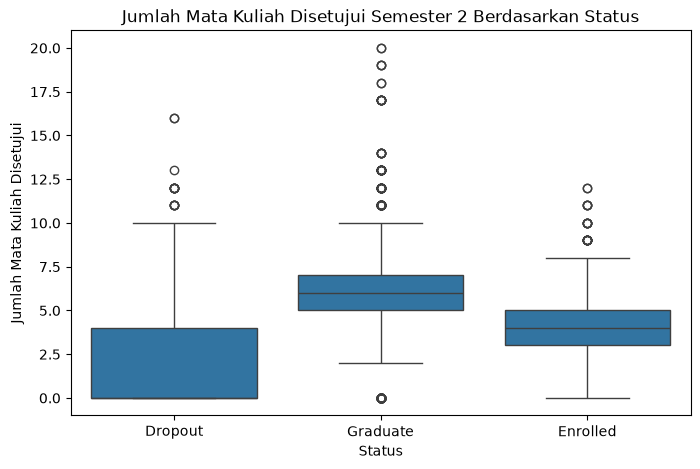

In [22]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Status",
    y="Curricular_units_2nd_sem_approved"
)

plt.title("Jumlah Mata Kuliah Disetujui Semester 2 Berdasarkan Status")
plt.xlabel("Status")
plt.ylabel("Jumlah Mata Kuliah Disetujui")
plt.show()

### Insight Performa Akademik

Berdasarkan hasil eksplorasi, terdapat perbedaan performa akademik yang cukup jelas antara mahasiswa dengan status Dropout, Enrolled, dan Graduate. Mahasiswa berstatus Dropout memiliki rata-rata jumlah mata kuliah yang disetujui dan nilai akademik yang lebih rendah dibandingkan mahasiswa berstatus Graduate maupun Enrolled.

Pada semester pertama, mahasiswa Dropout memiliki rata-rata jumlah mata kuliah yang disetujui sebesar 2,55 dengan rata-rata nilai 7,26. Sementara itu, mahasiswa Graduate memiliki rata-rata 6,23 mata kuliah yang disetujui dengan rata-rata nilai 12,64.

Pola yang serupa juga terlihat pada semester kedua. Mahasiswa Dropout memiliki rata-rata 1,94 mata kuliah yang disetujui dan rata-rata nilai 5,90, sedangkan mahasiswa Graduate memiliki rata-rata 6,18 mata kuliah yang disetujui dengan rata-rata nilai 12,70.

Temuan ini menunjukkan bahwa performa akademik merupakan salah satu aspek yang penting untuk diperhatikan dalam mendeteksi risiko dropout mahasiswa.

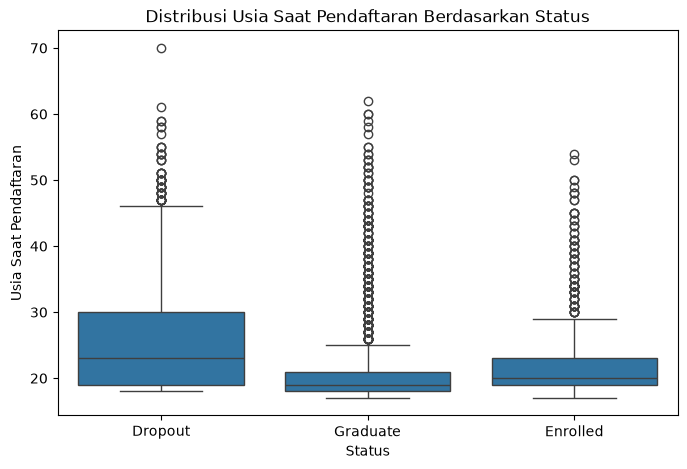

In [23]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Status",
    y="Age_at_enrollment"
)

plt.title("Distribusi Usia Saat Pendaftaran Berdasarkan Status")
plt.xlabel("Status")
plt.ylabel("Usia Saat Pendaftaran")
plt.show()

In [24]:
df.groupby("Status")["Age_at_enrollment"].mean().round(2)

Status
Dropout     26.07
Enrolled    22.37
Graduate    21.78
Name: Age_at_enrollment, dtype: float64

In [25]:
tuition_status = pd.crosstab(
    df["Status"],
    df["Tuition_fees_up_to_date"],
    normalize="index"
) * 100

tuition_status.round(2)

Tuition_fees_up_to_date,0,1
Status,,
Dropout,32.16,67.84
Enrolled,5.29,94.71
Graduate,1.31,98.69


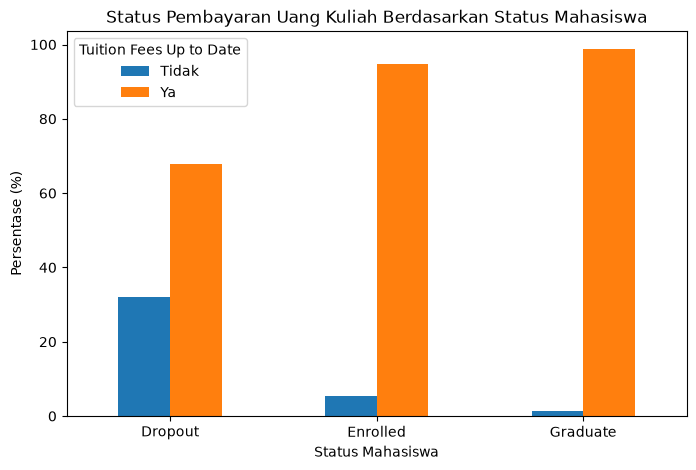

In [26]:
tuition_status.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Status Pembayaran Uang Kuliah Berdasarkan Status Mahasiswa")
plt.xlabel("Status Mahasiswa")
plt.ylabel("Persentase (%)")
plt.xticks(rotation=0)
plt.legend(
    title="Tuition Fees Up to Date",
    labels=["Tidak", "Ya"]
)
plt.show()

In [27]:
debtor_status = pd.crosstab(
    df["Status"],
    df["Debtor"],
    normalize="index"
) * 100

debtor_status.round(2)

Debtor,0,1
Status,,
Dropout,78.04,21.96
Enrolled,88.66,11.34
Graduate,95.43,4.57


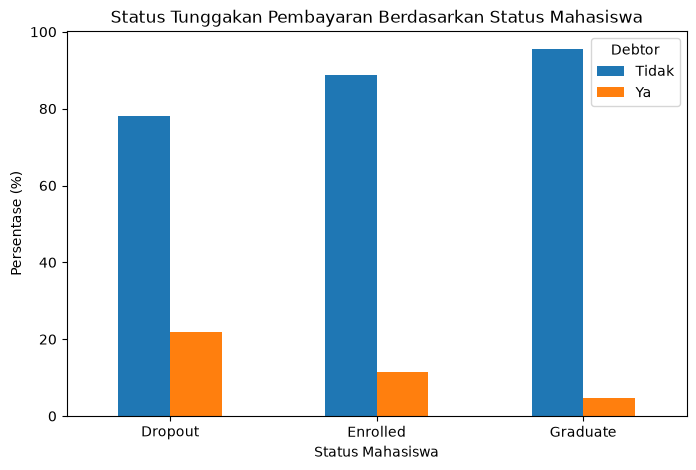

In [28]:
debtor_status.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Status Tunggakan Pembayaran Berdasarkan Status Mahasiswa")
plt.xlabel("Status Mahasiswa")
plt.ylabel("Persentase (%)")
plt.xticks(rotation=0)
plt.legend(
    title="Debtor",
    labels=["Tidak", "Ya"]
)
plt.show()

In [29]:
scholarship_status = pd.crosstab(
    df["Status"],
    df["Scholarship_holder"],
    normalize="index"
) * 100

scholarship_status.round(2)

Scholarship_holder,0,1
Status,,
Dropout,90.57,9.43
Enrolled,83.63,16.37
Graduate,62.20,37.80


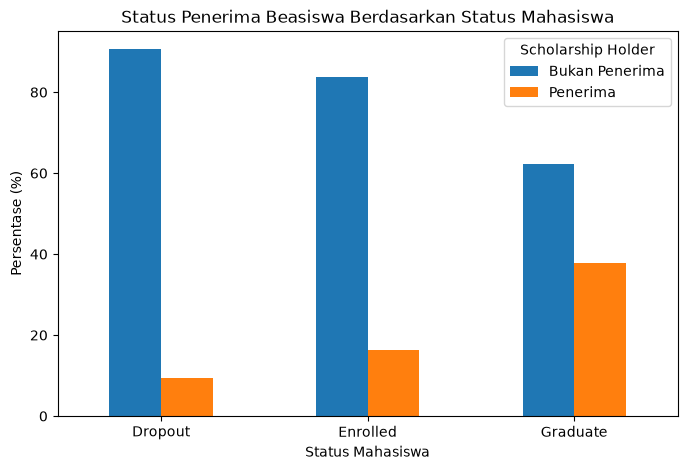

In [30]:
scholarship_status.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Status Penerima Beasiswa Berdasarkan Status Mahasiswa")
plt.xlabel("Status Mahasiswa")
plt.ylabel("Persentase (%)")
plt.xticks(rotation=0)
plt.legend(
    title="Scholarship Holder",
    labels=["Bukan Penerima", "Penerima"]
)
plt.show()

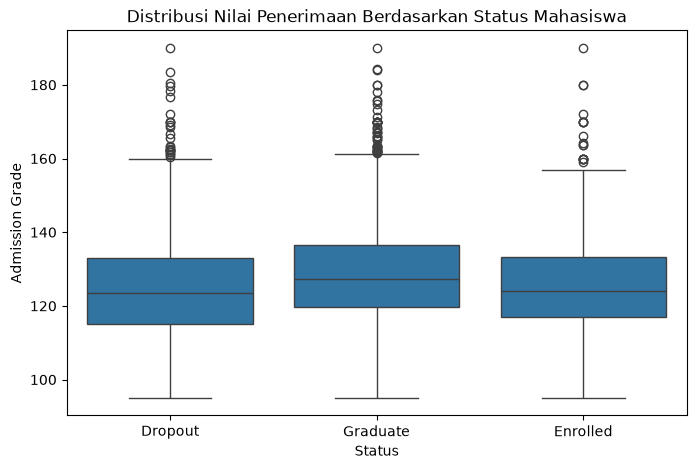

In [31]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Status",
    y="Admission_grade"
)

plt.title("Distribusi Nilai Penerimaan Berdasarkan Status Mahasiswa")
plt.xlabel("Status")
plt.ylabel("Admission Grade")
plt.show()

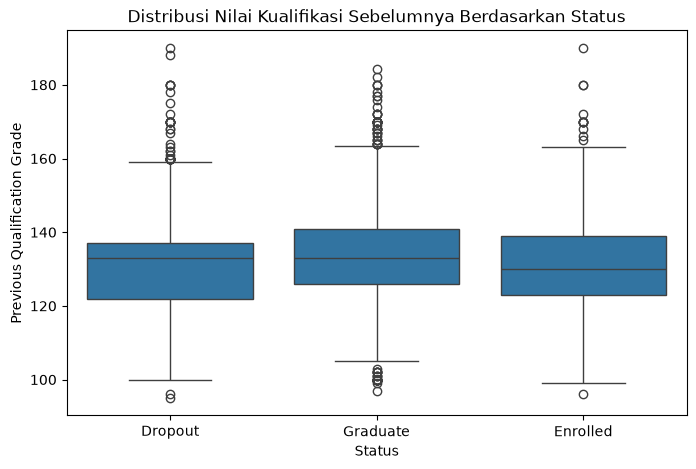

In [32]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Status",
    y="Previous_qualification_grade"
)

plt.title("Distribusi Nilai Kualifikasi Sebelumnya Berdasarkan Status")
plt.xlabel("Status")
plt.ylabel("Previous Qualification Grade")
plt.show()

In [33]:
status_mapping = {
    "Dropout": 0,
    "Enrolled": 1,
    "Graduate": 2
}

df_corr = df.copy()
df_corr["Status_encoded"] = df_corr["Status"].map(status_mapping)

correlation = df_corr.corr(numeric_only=True)["Status_encoded"].sort_values(
    ascending=False
)

correlation

Status_encoded                                  1.000000
Curricular_units_2nd_sem_approved               0.624157
Curricular_units_2nd_sem_grade                  0.566827
Curricular_units_1st_sem_approved               0.529123
Curricular_units_1st_sem_grade                  0.485207
Tuition_fees_up_to_date                         0.409827
Scholarship_holder                              0.297595
Curricular_units_2nd_sem_enrolled               0.175847
Curricular_units_1st_sem_enrolled               0.155974
Admission_grade                                 0.120889
Displaced                                       0.113986
Previous_qualification_grade                    0.103764
Curricular_units_2nd_sem_evaluations            0.092721
Application_order                               0.089791
Daytime_evening_attendance                      0.075107
Curricular_units_2nd_sem_credited               0.054004
Curricular_units_1st_sem_credited               0.048150
Curricular_units_1st_sem_evalua

In [34]:
top_correlations = (
    correlation
    .drop("Status_encoded")
    .abs()
    .sort_values(ascending=False)
    .head(10)
)

top_correlations

Curricular_units_2nd_sem_approved    0.624157
Curricular_units_2nd_sem_grade       0.566827
Curricular_units_1st_sem_approved    0.529123
Curricular_units_1st_sem_grade       0.485207
Tuition_fees_up_to_date              0.409827
Scholarship_holder                   0.297595
Age_at_enrollment                    0.243438
Debtor                               0.240999
Gender                               0.229270
Application_mode                     0.221747
Name: Status_encoded, dtype: float64

### Insight Faktor Non-Akademik

Hasil eksplorasi menunjukkan adanya beberapa perbedaan karakteristik antara mahasiswa berdasarkan statusnya. Mahasiswa berstatus Dropout memiliki rata-rata usia saat pendaftaran sebesar 26,07 tahun, lebih tinggi dibandingkan mahasiswa Enrolled sebesar 22,37 tahun dan Graduate sebesar 21,78 tahun.

Dari aspek pembayaran, 67,84% mahasiswa Dropout tercatat memiliki pembayaran uang kuliah yang tepat waktu, sedangkan pada mahasiswa Graduate proporsinya mencapai 98,69%. Selain itu, 21,96% mahasiswa Dropout tercatat memiliki status tunggakan pembayaran, dibandingkan dengan 4,57% pada mahasiswa Graduate.

Pada aspek beasiswa, hanya 9,43% mahasiswa Dropout yang merupakan penerima beasiswa, sedangkan proporsi penerima beasiswa pada mahasiswa Graduate mencapai 37,80%.

Analisis korelasi eksploratif juga menunjukkan bahwa variabel yang berkaitan dengan performa akademik memiliki hubungan paling kuat dengan status mahasiswa. Beberapa variabel dengan nilai korelasi absolut terbesar antara lain jumlah mata kuliah yang disetujui dan nilai akademik pada semester pertama dan kedua. Faktor lain seperti status pembayaran uang kuliah, penerima beasiswa, usia saat pendaftaran, dan status tunggakan juga menunjukkan hubungan dengan status mahasiswa.

Temuan tersebut menunjukkan bahwa karakteristik akademik dan beberapa faktor non-akademik dapat dipertimbangkan dalam pengembangan model untuk membantu institusi mengidentifikasi mahasiswa yang berisiko mengalami dropout.

## Data Preparation / Preprocessing

Pada tahap ini dilakukan persiapan data sebelum proses pemodelan. Target `Status` diubah menjadi dua kelas untuk menyesuaikan tujuan bisnis, yaitu mendeteksi mahasiswa yang berisiko mengalami dropout. Mahasiswa dengan status `Dropout` dikategorikan sebagai kelas `1`, sedangkan mahasiswa dengan status `Enrolled` dan `Graduate` dikategorikan sebagai kelas `0` atau Non-Dropout.

In [35]:
df["Target"] = (df["Status"] == "Dropout").astype(int)

df["Target"].value_counts()

Target
0    3003
1    1421
Name: count, dtype: int64

In [36]:
target_percentage = df["Target"].value_counts(normalize=True) * 100
target_percentage.round(2)

Target
0    67.88
1    32.12
Name: proportion, dtype: float64

In [37]:
X = df.drop(columns=["Status", "Target"])
y = df["Target"]

print("Jumlah fitur:", X.shape[1])
print("Jumlah data:", X.shape[0])

Jumlah fitur: 36
Jumlah data: 4424


In [38]:
categorical_features = [
    "Marital_status",
    "Application_mode",
    "Course",
    "Daytime_evening_attendance",
    "Previous_qualification",
    "Nacionality",
    "Mothers_qualification",
    "Fathers_qualification",
    "Mothers_occupation",
    "Fathers_occupation",
    "Displaced",
    "Educational_special_needs",
    "Debtor",
    "Tuition_fees_up_to_date",
    "Gender",
    "Scholarship_holder",
    "International"
]

numerical_features = [
    col for col in X.columns 
    if col not in categorical_features
]

print("Jumlah fitur kategorikal:", len(categorical_features))
print("Jumlah fitur numerik:", len(numerical_features))

Jumlah fitur kategorikal: 17
Jumlah fitur numerik: 19


In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Data training:", X_train.shape)
print("Data testing :", X_test.shape)

Data training: (3539, 36)
Data testing : (885, 36)


In [40]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

## Modeling

Pada tahap ini dilakukan pembangunan model klasifikasi untuk memprediksi apakah seorang mahasiswa berisiko mengalami dropout. Dua algoritma digunakan sebagai pembanding, yaitu Logistic Regression dan Random Forest.

Logistic Regression digunakan sebagai model baseline karena sederhana dan mudah diinterpretasikan, sedangkan Random Forest digunakan sebagai model pembanding yang mampu menangani hubungan yang lebih kompleks antarfitur.

Evaluasi model akan mempertimbangkan accuracy, precision, recall, dan F1-score. Karena tujuan utama model adalah membantu institusi mengidentifikasi mahasiswa yang berisiko dropout, recall pada kelas Dropout menjadi salah satu metrik utama dalam pemilihan model.

In [41]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        ))
    ]
)

In [42]:
logistic_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](36,)","['Marital_status','Application_mode','Application_order',..., 'Unemployment_rate','Inflation_rate','GDP']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,36
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By speci

In [43]:
y_pred_lr = logistic_model.predict(X_test)

In [44]:
print("Logistic Regression")
print("=" * 30)

print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1-score :", f1_score(y_test, y_pred_lr))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_lr,
    target_names=["Non-Dropout", "Dropout"]
))

Logistic Regression
Accuracy : 0.880225988700565
Precision: 0.7966666666666666
Recall   : 0.8415492957746479
F1-score : 0.8184931506849316

Classification Report:
              precision    recall  f1-score   support

 Non-Dropout       0.92      0.90      0.91       601
     Dropout       0.80      0.84      0.82       284

    accuracy                           0.88       885
   macro avg       0.86      0.87      0.86       885
weighted avg       0.88      0.88      0.88       885



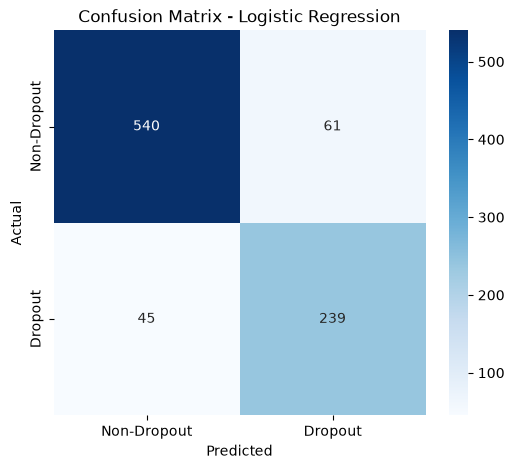

In [45]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Non-Dropout", "Dropout"],
    yticklabels=["Non-Dropout", "Dropout"]
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [46]:
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            class_weight="balanced"
        ))
    ]
)

In [47]:
random_forest_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](36,)","['Marital_status','Application_mode','Application_order',..., 'Unemployment_rate','Inflation_rate','GDP']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,36
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By speci

In [48]:
y_pred_rf = random_forest_model.predict(X_test)

In [49]:
print("Random Forest")
print("=" * 30)

print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1-score :", f1_score(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_rf,
    target_names=["Non-Dropout", "Dropout"]
))

Random Forest
Accuracy : 0.8768361581920904
Precision: 0.8205128205128205
Recall   : 0.7887323943661971
F1-score : 0.8043087971274686

Classification Report:
              precision    recall  f1-score   support

 Non-Dropout       0.90      0.92      0.91       601
     Dropout       0.82      0.79      0.80       284

    accuracy                           0.88       885
   macro avg       0.86      0.85      0.86       885
weighted avg       0.88      0.88      0.88       885



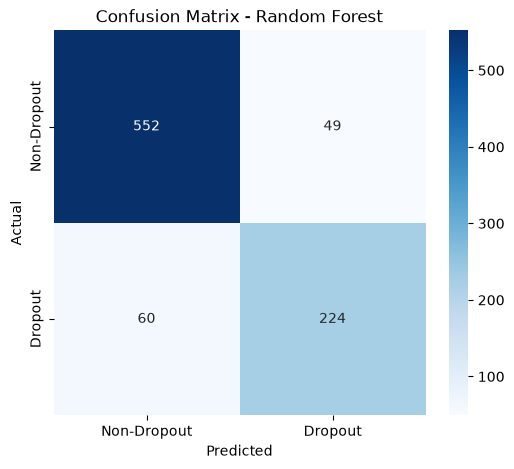

In [50]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Non-Dropout", "Dropout"],
    yticklabels=["Non-Dropout", "Dropout"]
)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [51]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf)
    ],
    "F1-Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf)
    ]
})

model_comparison.round(4)

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.8802,0.7967,0.8415,0.8185
1,Random Forest,0.8768,0.8205,0.7887,0.8043


## Evaluation